In [1]:
import os
import re
import glob
import numpy as np
import matplotlib.pyplot as plt

In [2]:
BaseDir   = ('/Users/sukantabasu/Dropbox/Codes/LES/JAX-ALFA/JAXALFA0.1/')

# CaseDir1   = os.path.join(BaseDir, 'examples/CBL_N91/runs/64x64x64/')
# OutputDir1A = os.path.join(CaseDir1, 'output/') # double precision
# OutputDir1B = os.path.join(CaseDir1, 'output_SP/') # single precision

CaseDir2   = os.path.join(BaseDir, 'examples/CBL_N91/runs/96x96x96/')
OutputDir2A = os.path.join(CaseDir2, 'output_damp50dt/') # double precision
OutputDir2B = os.path.join(CaseDir2, 'output_damp20dt/') # single precision

CaseDir3   = os.path.join(BaseDir, 'examples/CBL_N91/runs/192x192x192/')
OutputDir3A = os.path.join(CaseDir3, 'output/') # double precision
# OutputDir3B = os.path.join(CaseDir3, 'output_SP/') # single precision

In [3]:
OutputFiles2A = os.path.join(OutputDir2A, 'ALFA_3DFields_Iteration_3600.npz')
File3D_2A = np.load(OutputFiles2A)
w3D_2A = File3D_2A['w']
TH3D_2A = File3D_2A['TH']

In [4]:
OutputFiles3A = os.path.join(OutputDir3A, 'ALFA_3DFields_Iteration_7200.npz')
File3D_3A = np.load(OutputFiles3A)
w3D_3A = File3D_3A['w']
TH3D_3A = File3D_3A['TH']

# OutputFiles3B = os.path.join(OutputDir3B, 'ALFA_3DFields_Iteration_12600.npz')
# File3D_3B = np.load(OutputFiles3B)
# w3D_3B = File3D_3B['w']
# TH3D_3B = File3D_3B['TH']

In [5]:
# plt.figure(figsize=(8, 8))

# im = plt.pcolor(w3D_2A[:,:,4], cmap='inferno')

# cbar = plt.colorbar(im, pad=0.02)
# cbar.set_label('Vertical Velocity (w)', fontsize=12)

# plt.xlabel('X direction', fontsize=12)
# plt.ylabel('Y direction', fontsize=12)
# plt.title('Vertical Velocity Field at Z=5', fontsize=14)

# plt.axis('equal')
# plt.axis('tight')
# plt.tight_layout()
# plt.show()

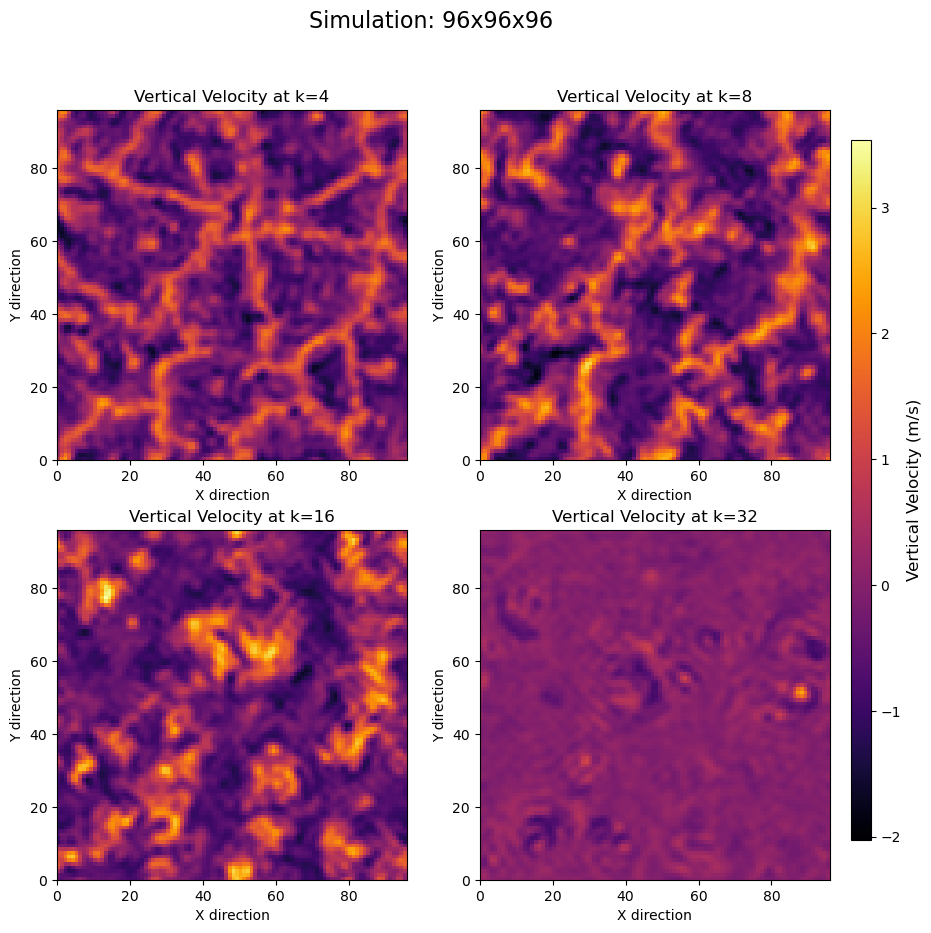

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

k_levels = [4, 8, 16, 32]  # Adjust these based on your data dimensions

# Flatten the axes array for easier indexing
axes = axes.flatten()

# Create a common colorbar range for consistent visualization
vmin = np.min(w3D_2A[:,:,k_levels])
vmax = np.max(w3D_2A[:,:,k_levels])

# Plot each z level in a different subplot
for i, k in enumerate(k_levels):
    im = axes[i].pcolor(w3D_2A[:,:,k], cmap='inferno', vmin=vmin, vmax=vmax)
    axes[i].set_title(f'Vertical Velocity at k={k}', fontsize=12)
    axes[i].set_aspect('equal')
    axes[i].set_xlabel('X direction')
    axes[i].set_ylabel('Y direction')

# Add a colorbar that applies to all subplots
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('Vertical Velocity (m/s)', fontsize=12)

# Adjust layout and spacing
# plt.tight_layout(rect=[0, 0, 0.9, 1])  # Make room for the colorbar
plt.suptitle('Simulation: 96x96x96', fontsize=16, y=0.98)

# Show the plot
plt.show()

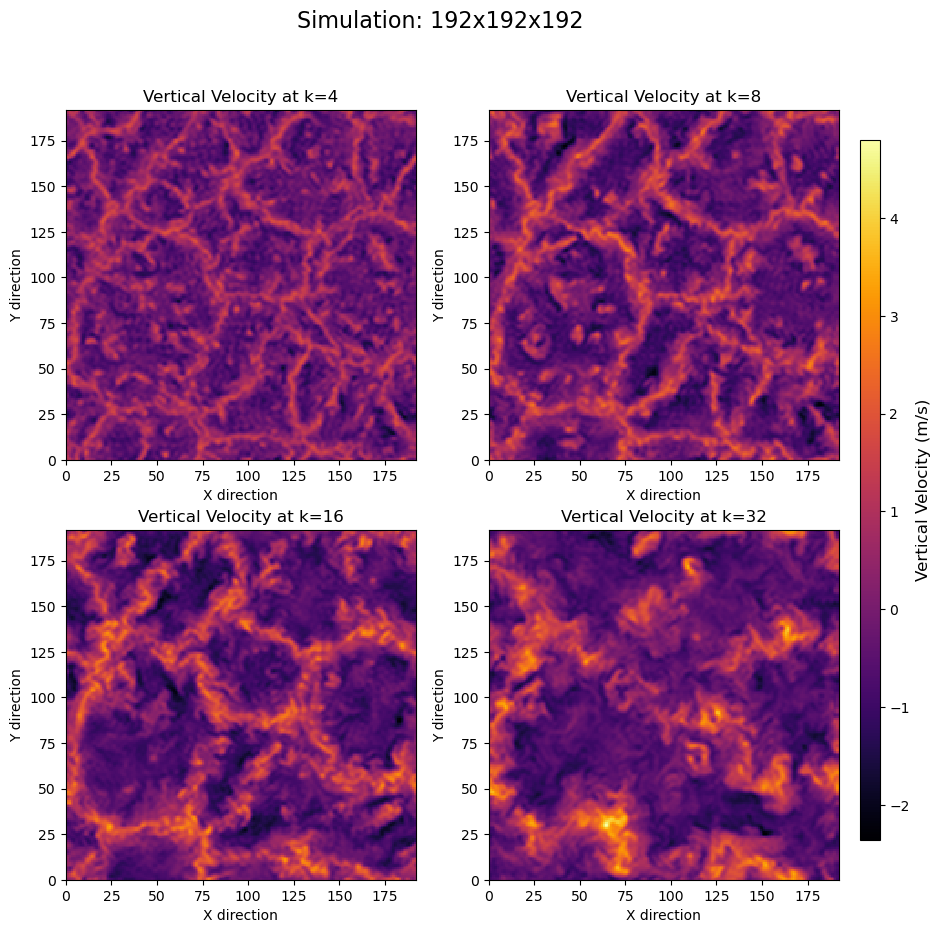

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

k_levels = [4, 8, 16, 32]  # Adjust these based on your data dimensions

# Flatten the axes array for easier indexing
axes = axes.flatten()

# Create a common colorbar range for consistent visualization
vmin = np.min(w3D_3A[:,:,k_levels])
vmax = np.max(w3D_3A[:,:,k_levels])

# Plot each z level in a different subplot
for i, k in enumerate(k_levels):
    im = axes[i].pcolor(w3D_3A[:,:,k], cmap='inferno', vmin=vmin, vmax=vmax)
    axes[i].set_title(f'Vertical Velocity at k={k}', fontsize=12)
    axes[i].set_aspect('equal')
    axes[i].set_xlabel('X direction')
    axes[i].set_ylabel('Y direction')

# Add a colorbar that applies to all subplots
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('Vertical Velocity (m/s)', fontsize=12)

# Adjust layout and spacing
# plt.tight_layout(rect=[0, 0, 0.9, 1])  # Make room for the colorbar
plt.suptitle('Simulation: 192x192x192', fontsize=16, y=0.98)

# Show the plot
plt.show()

In [8]:
# fig, axes = plt.subplots(2, 2, figsize=(10, 10))
# 
# k_levels = [4, 8, 16, 32]  # Adjust these based on your data dimensions
# 
# # Flatten the axes array for easier indexing
# axes = axes.flatten()
# 
# # Create a common colorbar range for consistent visualization
# vmin = np.min(w3D_3B[:,:,k_levels])
# vmax = np.max(w3D_3B[:,:,k_levels])
# 
# # Plot each z level in a different subplot
# for i, k in enumerate(k_levels):
#     im = axes[i].pcolor(w3D_3B[:,:,k], cmap='inferno', vmin=vmin, vmax=vmax)
#     axes[i].set_title(f'Vertical Velocity at k={k}', fontsize=12)
#     axes[i].set_aspect('equal')
#     axes[i].set_xlabel('X direction')
#     axes[i].set_ylabel('Y direction')
# 
# # Add a colorbar that applies to all subplots
# cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
# cbar = fig.colorbar(im, cax=cbar_ax)
# cbar.set_label('Vertical Velocity (m/s)', fontsize=12)
# 
# # Adjust layout and spacing
# # plt.tight_layout(rect=[0, 0, 0.9, 1])  # Make room for the colorbar
# plt.suptitle('Simulation: 128x128x128 (SP)', fontsize=16, y=0.98)
# 
# # Show the plot
# plt.show()

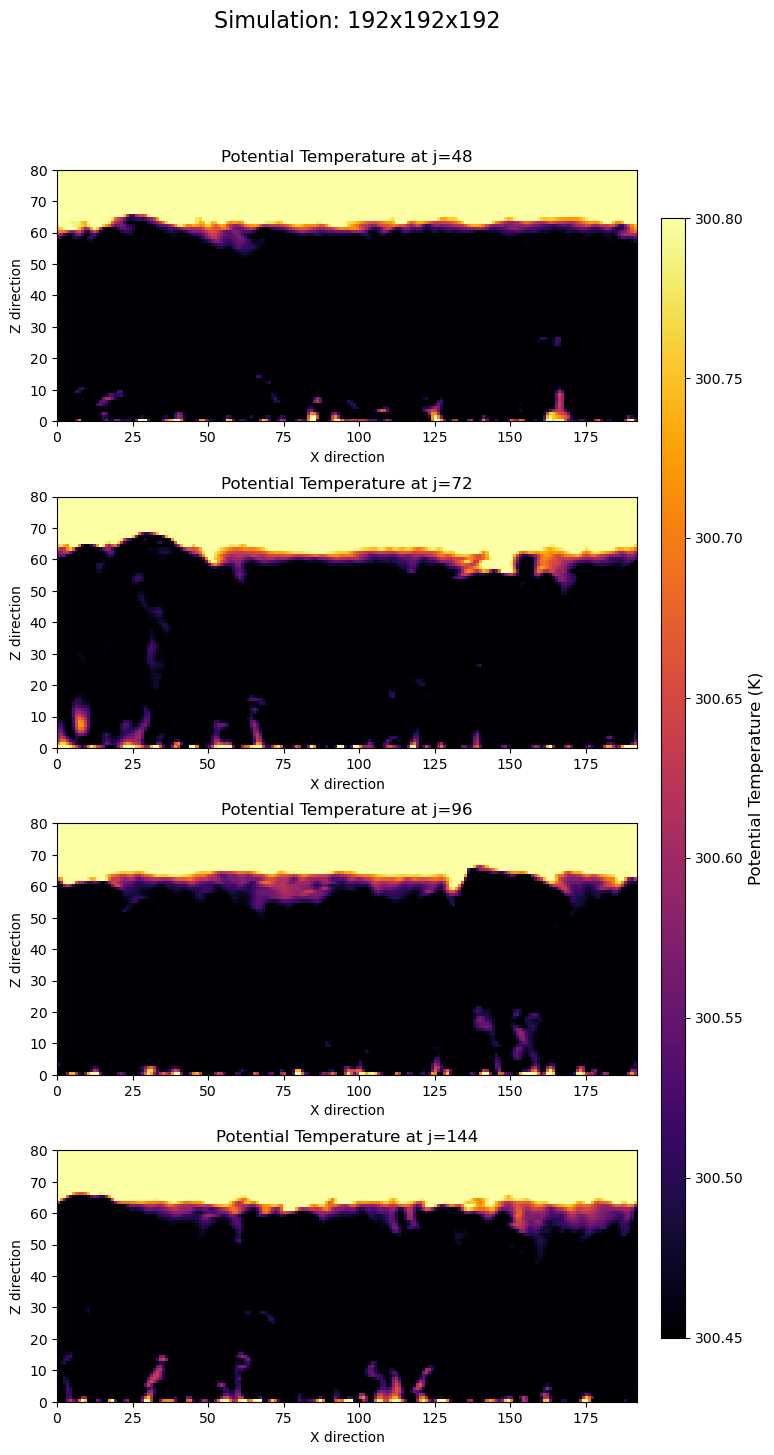

In [9]:
fig, axes = plt.subplots(4, 1, figsize=(8, 16))  # 4 rows, 1 column with taller figure

j_levels = [48, 72, 96, 144]  # Your selected j-levels

# Create a common colorbar range for consistent visualization
vmin = 300.45
vmax = 300.8

# Plot each j level in a different subplot
for i, j in enumerate(j_levels):
    im = axes[i].pcolor(TH3D_3A[:,j,:].T, cmap='inferno', vmin=vmin, vmax=vmax)
    axes[i].set_title(f'Potential Temperature at j={j}', fontsize=12)
    axes[i].set_xlabel('X direction')
    axes[i].set_ylabel('Z direction')
    axes[i].set_ylim(0, 80)
    # Make the plots more elongated
    axes[i].set_aspect('auto')  # Changed from 'equal' to 'auto' for elongated plots

# Adjust spacing between subplots first
plt.subplots_adjust(hspace=0.3, right=0.85)  # Add space between subplots and make room for colorbar

# Add a colorbar that applies to all subplots
cbar_ax = fig.add_axes([0.88, 0.15, 0.03, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('Potential Temperature (K)', fontsize=12)

# Add title
plt.suptitle('Simulation: 192x192x192', fontsize=16, y=0.98)

# Show the plot
plt.show()

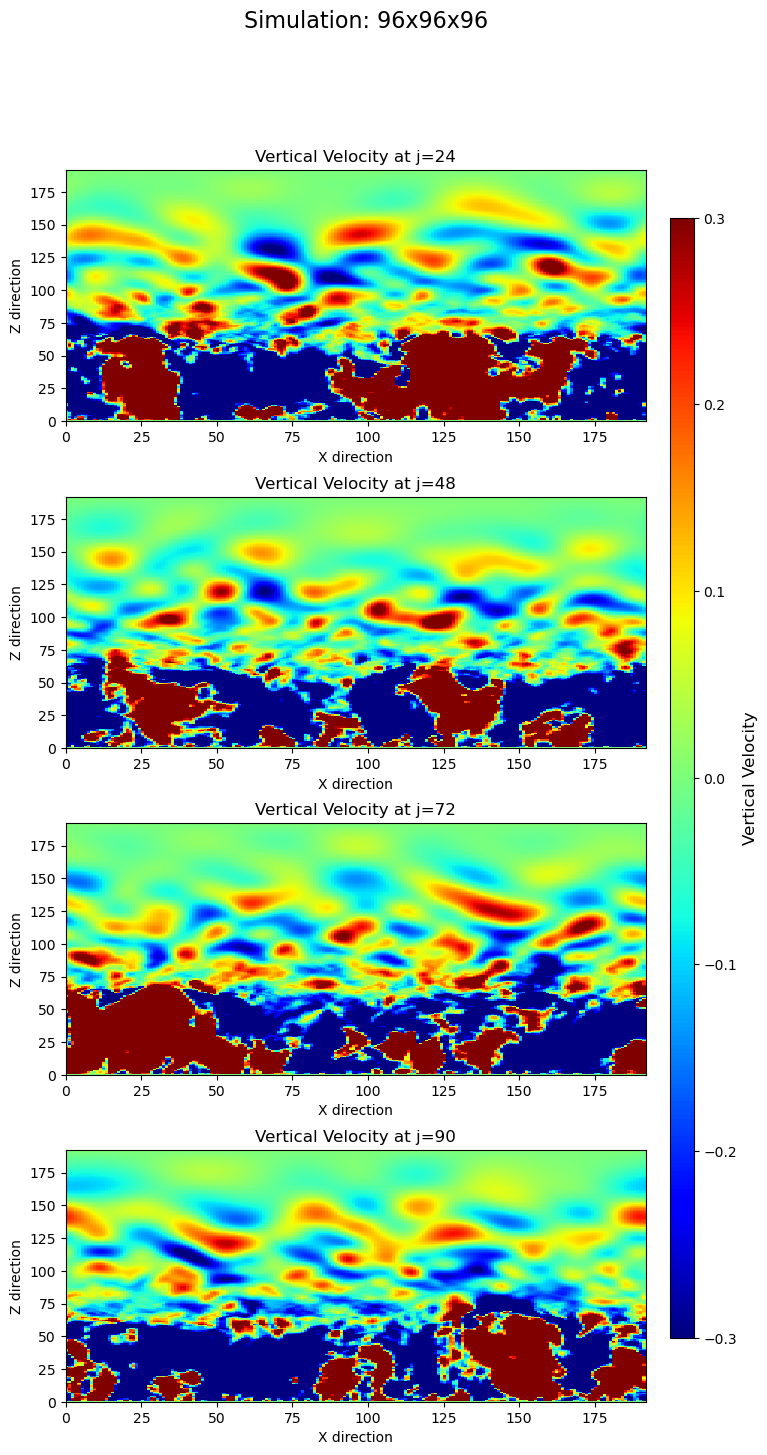

In [10]:
fig, axes = plt.subplots(4, 1, figsize=(8, 16))  # 4 rows, 1 column with taller figure

j_levels = [24, 48, 72, 90]  # Your selected j-levels

# Create a common colorbar range for consistent visualization
vmin = -0.3
vmax = 0.3

# Plot each j level in a different subplot
for i, j in enumerate(j_levels):
    im = axes[i].pcolor(w3D_3A[:,j,:].T, cmap='jet', vmin=vmin, vmax=vmax)
    axes[i].set_title(f'Vertical Velocity at j={j}', fontsize=12)
    axes[i].set_xlabel('X direction')
    axes[i].set_ylabel('Z direction')
    axes[i].set_ylim(0, 192)
    # Make the plots more elongated
    axes[i].set_aspect('auto')  # Changed from 'equal' to 'auto' for elongated plots

# Adjust spacing between subplots first
plt.subplots_adjust(hspace=0.3, right=0.85)  # Add space between subplots and make room for colorbar

# Add a colorbar that applies to all subplots
cbar_ax = fig.add_axes([0.88, 0.15, 0.03, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('Vertical Velocity', fontsize=12)

# Add title
plt.suptitle('Simulation: 96x96x96', fontsize=16, y=0.98)

# Show the plot
plt.show()